### 12. Churn Analysis & Drivers

**Goal:** 
- Identify characteristics of churned customers
- Compare churned vs active users
- Detect key behavioral patterns leading to churn
- Provide actionable insights for retention


In [1]:
# Loading necessary libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from local_config import *

engine = create_engine(
    f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
)

df = pd.read_sql("SELECT * FROM analytics.customer_features", engine)

In [2]:
# Exploring the data
#df.head()
#df.info()
#df.describe()

In [3]:
# -------------------------
# Data preparation
# -------------------------
# Flag for single-order customers
df['is_single_order'] = df['avg_days_between_orders'].isna().astype(int)
df['days_between_orders'] = df['avg_days_between_orders'].fillna(0)

categorical_cols = ['value_segment', 'lifecycle_segment']
numerical_cols = [
    'recency_days',
    'frequency',
    'monetary_usd',
    'avg_order_value',
    'avg_days_between_orders',
    'order_count_last_30d',
    'order_count_last_60d'
]

### 1. Churn Rate Overview


In [4]:
churned_proportion = (
    df['is_churned']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)
print("Churn distribution (%)")
print(churned_proportion)

Churn distribution (%)
   is_churned  proportion
0           0        66.7
1           1        33.3


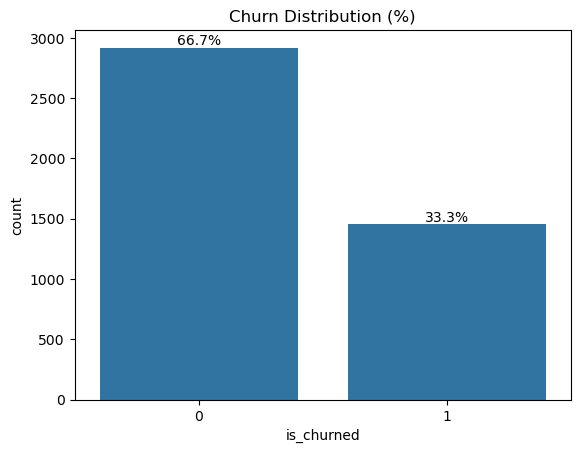

In [5]:
# Countplot with percentages
ax = sns.countplot(x='is_churned', data=df)
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.title('Churn Distribution (%)')
plt.show()

### Insights
- Approximately 33% of customers have churned, while 67% remain active.
- This indicates a moderate churn rate, suggesting that a significant portion of users disengage after initial interactions.
- The dataset is slightly imbalanced, which should be considered during modeling.

---

### 2. Numerical Features vs Churn

In [6]:
# 2.1 Recency Analysis
recency = df.groupby('is_churned')['recency_days']
recency_iqr_df = pd.concat([
    recency.quantile(0.25).rename('Q1'),
    recency.quantile(0.5).rename('Median'),
    recency.quantile(0.75).rename('Q3')
], axis=1)
print('Recency vs Churn')
print(recency_iqr_df)

Recency vs Churn
               Q1  Median     Q3
is_churned                      
0             9.0    24.0   50.0
1           143.0   204.5  277.0


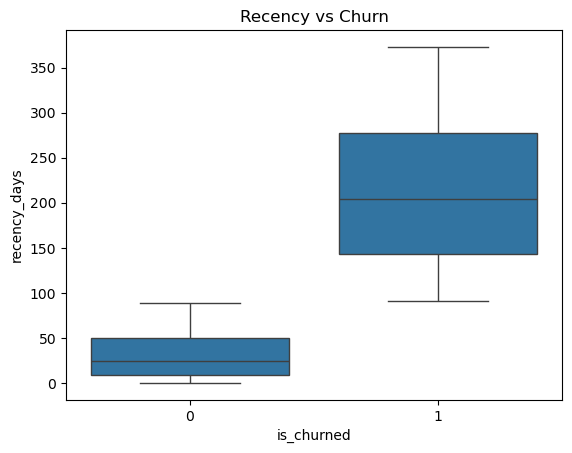

In [7]:
sns.boxplot(x='is_churned', y='recency_days', data=df)
plt.title('Recency vs Churn')
plt.show()

### Insights
- Churned customers have significantly higher recency,
- indicating that inactivity is a strong signal of churn.

---

In [8]:
# 2.2 Frequency Analysis
frequency = df.groupby('is_churned')['frequency']
frequency_iqr_df = pd.concat([
    frequency.quantile(0.25).rename('Q1'),
    frequency.quantile(0.5).rename('Median'),
    frequency.quantile(0.75).rename('Q3')
], axis=1)
print('Frequency vs Churn')
print(frequency_iqr_df)

Frequency vs Churn
             Q1  Median   Q3
is_churned                  
0           2.0     4.0  7.0
1           1.0     1.0  2.0


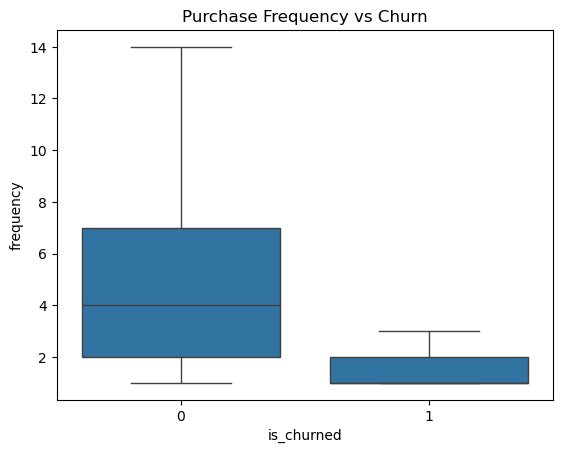

In [9]:
sns.boxplot(x='is_churned', y='frequency', data=df, showfliers=False)
plt.title('Purchase Frequency vs Churn')
plt.show()

### Insights
 Churned users tend to have lower purchase frequency, suggesting weaker engagement with the product.

---

In [10]:
# 2.3 Monetary Analysis
monetary = df.groupby('is_churned')['monetary_usd']
monetary_iqr_df = pd.concat([
    monetary.quantile(0.25).rename('Q1'),
    monetary.quantile(0.5).rename('Median'),
    monetary.quantile(0.75).rename('Q3')
], axis=1)
print('Monetary vs Churn')
print(monetary_iqr_df)

Monetary vs Churn
                  Q1   Median        Q3
is_churned                             
0           37755.25  88670.0  203296.5
1           15737.50  30579.5   59400.0


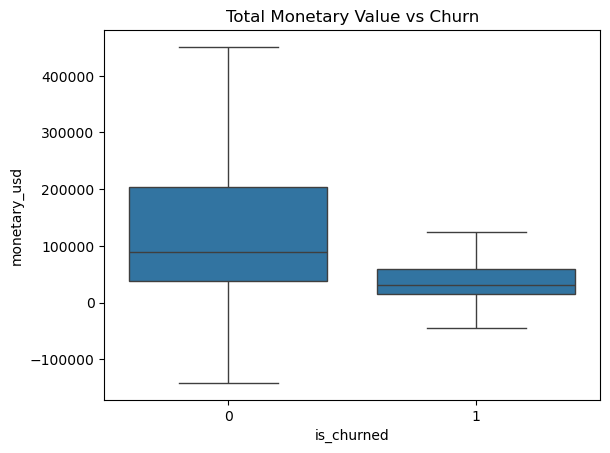

In [11]:
sns.boxplot(x='is_churned', y='monetary_usd', data=df, showfliers=False)
plt.title('Total Monetary Value vs Churn')
plt.show()

### Insights
- Churned users have significantly lower total spending compared to active users (median $30,580 vs $88,670), indicating that customer value is strongly associated with retention. 
- While behavioral metrics like recency and recent activity are important predictors, monetary value also clearly differentiates churned and active customers.
---

In [12]:
# 2.4 Recent Activity
recent_activity_median = df.groupby('is_churned')[['order_count_last_30d', 'order_count_last_60d']].median()
print("Median Recent Orders (Last 30d & 60d) by Churn Status")
print(recent_activity_median)

Median Recent Orders (Last 30d & 60d) by Churn Status
            order_count_last_30d  order_count_last_60d
is_churned                                            
0                            1.0                   1.0
1                            0.0                   0.0


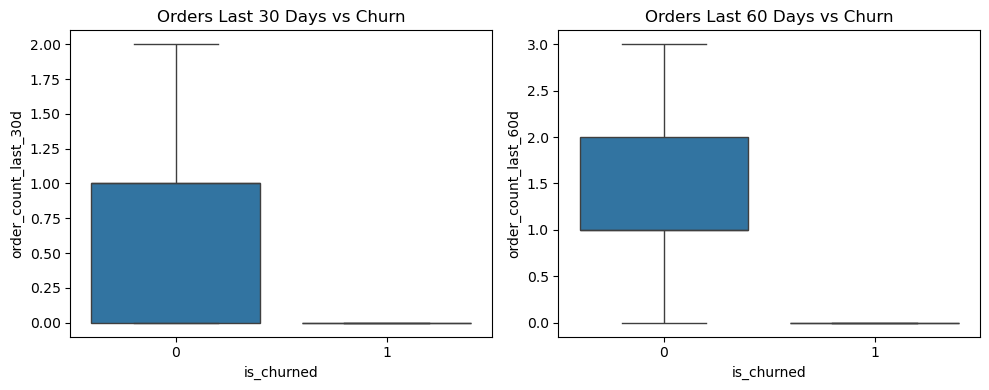

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(x='is_churned', y='order_count_last_30d', data=df, showfliers=False, ax=ax[0])
ax[0].set_title('Orders Last 30 Days vs Churn')


sns.boxplot(x='is_churned', y='order_count_last_60d', data=df, showfliers=False, ax=ax[1])
ax[1].set_title('Orders Last 60 Days vs Churn')

plt.tight_layout()
plt.show()

### Insights
- Churned users show near-zero activity in recent periods, making recent engagement a strong leading indicator of churn.

---

In [14]:
# 2.5 Avg Days Between Orders
days_between_orders = df.groupby('is_churned')['avg_days_between_orders']
days_between_orders_iqr_df = pd.concat([
    days_between_orders.quantile(0.25).rename('Q1'),
    days_between_orders.quantile(0.5).rename('Median'),
    days_between_orders.quantile(0.75).rename('Q3')
], axis=1)
print('Avg Days Between Orders vs Churn')
print(days_between_orders_iqr_df)

Avg Days Between Orders vs Churn
              Q1  Median     Q3
is_churned                     
0           23.0    42.0  77.00
1           14.0    40.0  71.25


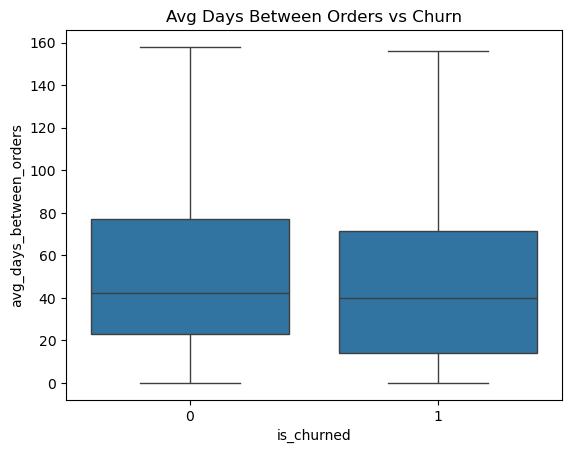

In [15]:
sns.boxplot(x='is_churned', y='avg_days_between_orders', data=df, showfliers=False)
plt.title('Avg Days Between Orders vs Churn')
plt.show()

### Insights
- Churned users tend to have slightly higher average days between orders, but the difference is less pronounced than recency or recent activity metrics.

---

### 3. Segment Analysis
**Goal**: 
Identify which customer segments have the highest churn rates 
and where retention efforts should be focused.

In [16]:
# 3.1 Churn by Value Segment

value_churn = pd.crosstab(
    df['value_segment'],
    df['is_churned'],
    normalize='index'
)

print(value_churn)

is_churned            0         1
value_segment                    
High-value     0.897104  0.102896
Low-value      0.432165  0.567835
Mid-value      0.671625  0.328375


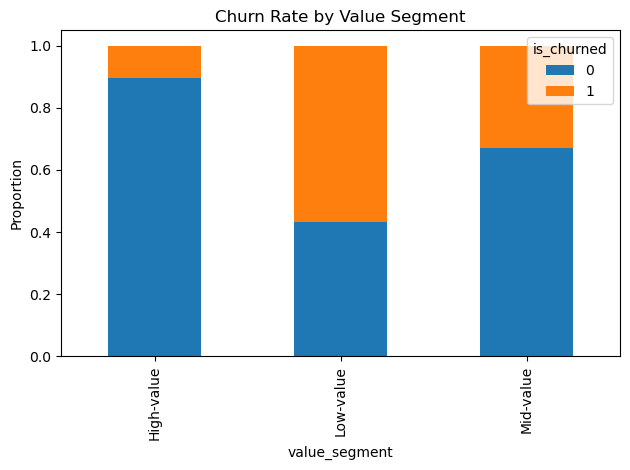

In [17]:
value_churn.plot(kind='bar', stacked=True)
plt.title('Churn Rate by Value Segment')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()

### Insights
Low-value customers exhibit the highest churn rates, while high-value customers are significantly more likely to be retained.

This suggests that customer value is strongly associated with retention.

In [18]:
# 3.2 Churn by Lifecycle Segment

Lifecycle segments are derived using recency and tenure, 
which are also used in churn definition. Therefore, churn comparison across these segments is not meaningful.

In [19]:
# 3.3 Segment Size + Churn
# Segment size
segment_size = (
    df['value_segment']
    .value_counts(normalize=True)
    .rename('size')
)

# Churn rate 
segment_churn = value_churn[1].rename('churn')

# Merge
segment_size_churn = (
    pd.concat([segment_size, segment_churn], axis=1)
    .reset_index()
    .rename(columns={'index': 'segment'})
    .sort_values(by='churn', ascending=False)
)

# Add metric impact
segment_size_churn['churn_contribution'] = (
    segment_size_churn['size'] * segment_size_churn['churn']
)

print(segment_size_churn)

  value_segment      size     churn  churn_contribution
1     Low-value  0.300091  0.567835            0.170403
0     Mid-value  0.399817  0.328375            0.131290
2    High-value  0.300091  0.102896            0.030878


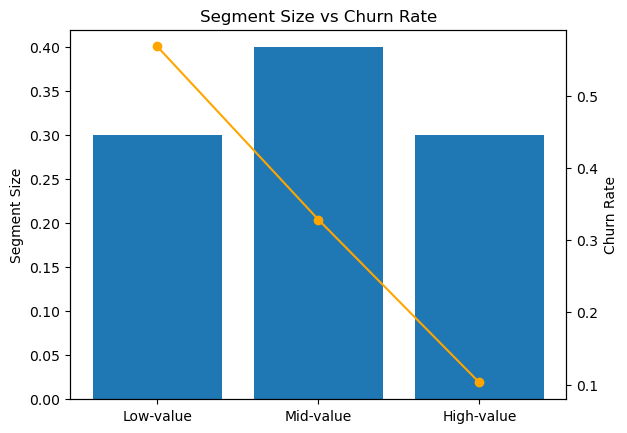

In [20]:
fig, ax1 = plt.subplots()

# Bar chart — segment size
ax1.bar(segment_size_churn['value_segment'], segment_size_churn['size'])
ax1.set_ylabel('Segment Size')
ax1.set_title('Segment Size vs Churn Rate')

# Line chart — churn rate
ax2 = ax1.twinx()
ax2.plot(segment_size_churn['value_segment'], segment_size_churn['churn'], marker='o', color = 'orange')
ax2.set_ylabel('Churn Rate')

plt.show()

### Insights
Low-value customers contribute the most to total churn, 
as they combine both high churn rates and a substantial share of the customer base.

In contrast, high-value customers, despite a similar segment size, 
have a minimal contribution to churn due to strong retention.

### 4. Churn Drivers Analysis

In [21]:
# Correlation between numerical features
num_features_churn_corr = df[numerical_cols + ['is_churned']].corr()[['is_churned']].sort_values('is_churned', ascending=False)
num_features_churn_corr

,is_churned
is_churned,1.000000
recency_days,0.858932
avg_days_between_orders,-0.061125
avg_order_value,-0.078889
monetary_usd,-0.114073
frequency,-0.222616
order_count_last_30d,-0.322691
order_count_last_60d,-0.359805


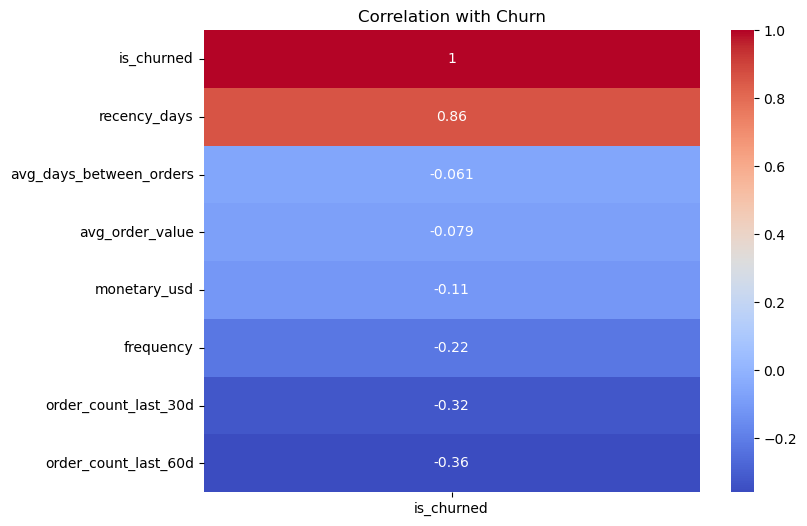

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(num_features_churn_corr,
            annot=True, cmap='coolwarm')
plt.title('Correlation with Churn')
plt.show()

Recency shows a very strong correlation with churn, as it is directly used in the churn definition.

Other features (recent activity, frequency, monetary) show weaker linear correlations, 
but still demonstrate meaningful differences when comparing churned vs active users.

In [23]:
driver_summary = df.groupby('is_churned')[numerical_cols].median().T
driver_summary['diff'] = driver_summary[1] - driver_summary[0]
driver_summary['diff_pct'] = (driver_summary[1] - driver_summary[0]) / driver_summary[0]
driver_summary = driver_summary.sort_values(by='diff_pct', ascending=False)

driver_summary

is_churned,0,1,diff,diff_pct
recency_days,24.00,204.5,180.50,7.520833
avg_days_between_orders,42.00,40.0,-2.00,-0.047619
avg_order_value,23091.71,18795.5,-4296.21,-0.186050
monetary_usd,88670.00,30579.5,-58090.50,-0.655131
frequency,4.00,1.0,-3.00,-0.750000
order_count_last_30d,1.00,0.0,-1.00,-1.000000
order_count_last_60d,1.00,0.0,-1.00,-1.000000


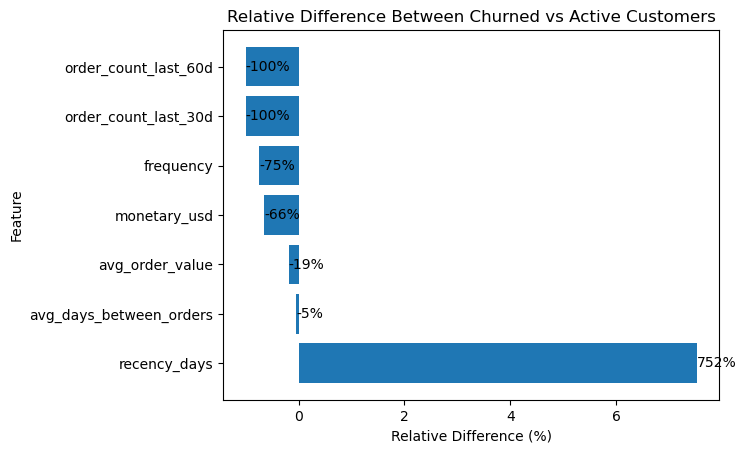

In [24]:
plt.figure()

bars = plt.barh(
    driver_summary.index,
    driver_summary['diff_pct']
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.0%}',
        va='center'
    )

plt.title('Relative Difference Between Churned vs Active Customers')
plt.xlabel('Relative Difference (%)')
plt.ylabel('Feature')

plt.show()

### Insights
The largest behavioral differences between churned and active users are observed in:

- Recency → churned users show significantly higher inactivity
- Recent activity → orders in the last 30–60 days drop to near zero
- Frequency → churned users place substantially fewer orders

Monetary-related features also differ, but to a lesser extent in relative terms.

Overall, engagement-related metrics show the strongest relative decline, 
confirming that churn is primarily driven by decreasing user activity.

-------------------

### Behavioral Patterns of Churned Customers

Based on the comparative analysis of churned vs active users, several consistent behavioral patterns emerge:

- High recency → by definition, churned users have not made a purchase for 90+ days; this threshold is data-driven, as the probability of customer return drops significantly after this period
- Near-zero recent activity → orders in the last 30–60 days drop to nearly zero, representing one of the strongest independent signals of churn
- Low frequency → churned users place significantly fewer orders over their lifetime, indicating weaker overall engagement
- Lower monetary value → median customer spending is ~3x lower compared to active users, highlighting a strong relationship between customer value and retention
- Avg days between orders → shows only minor differences, suggesting it is a weaker signal compared to other behavioral metrics

Overall, churn appears to be driven by a gradual decline in customer engagement rather than a single event. 
The most prominent signals are related to recent activity and interaction frequency, 
which provide meaningful insights beyond the churn definition itself.

### 5. Logistic Regression

In [25]:
# 1. Feature Selection
features = [
    'frequency',
    'monetary_usd',
    'avg_order_value',
    'days_between_orders',   
    'is_single_order',       
    'order_count_last_30d',
    'order_count_last_60d'
]

X = df[features].fillna(0)
y = df['is_churned']

In [26]:
# 2. Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [27]:
# 3. Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [28]:
# 4. Coefficients
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', ascending=False)

print(coef_df)

                feature  coefficient
1          monetary_usd    -0.000002
2       avg_order_value    -0.000004
3   days_between_orders    -0.009841
0             frequency    -0.203543
4       is_single_order    -0.727485
5  order_count_last_30d    -2.592806
6  order_count_last_60d    -5.255785


In [29]:
# 5.Odds Ratio

coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df

,feature,coefficient,odds_ratio
1,monetary_usd,-0.000002,0.999998
2,avg_order_value,-0.000004,0.999996
3,days_between_orders,-0.009841,0.990208
0,frequency,-0.203543,0.815835
4,is_single_order,-0.727485,0.483123
5,order_count_last_30d,-2.592806,0.074810
6,order_count_last_60d,-5.255785,0.005217


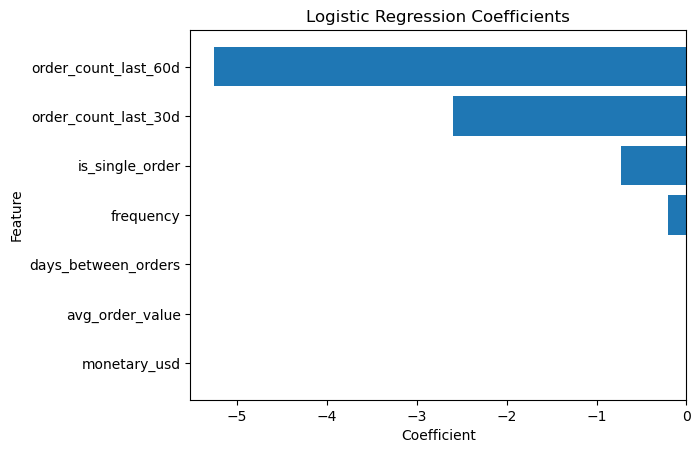

In [30]:
plt.figure()

plt.barh(coef_df['feature'], coef_df['coefficient'])

plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

### Insights
Logistic regression results confirm that engagement-related features 
are the strongest predictors of churn.

- Recent activity (orders in the last 30–60 days) has the largest impact on churn probability
- Purchase frequency is also a strong predictor, with more frequent customers being less likely to churn
- Monetary-related features show a weaker effect, indicating that behavior is more important than value

This aligns with previous analysis, where recent activity and frequency 
were identified as the strongest behavioral differences between churned and active users.

Some coefficients (e.g., is_single_order) may appear counterintuitive due to multicollinearity between related features. 
Therefore, results should be interpreted at an aggregate level rather than feature-by-feature.

Overall, the model reinforces earlier findings: 
churn is primarily driven by declining customer engagement.

*The model is used for interpretability rather than prediction accuracy. Recency is excluded to avoid data leakage, as it is part of the churn definition.*

---

## Insights & Recommendations

### 🔍 Key Insights

1. **Churn is primarily driven by declining engagement**
- Customers who churn show a sharp drop in activity before leaving
- Orders in the last 30–60 days are near zero for churned users
- Purchase frequency is significantly lower compared to active users

2. **Recency is a strong indicator, but part of churn definition**
- Customers inactive for 90+ days are classified as churned
- This threshold is data-driven, as the probability of return drops significantly after this period

3. **Customer value is strongly linked to retention**
- High-value customers have significantly lower churn rates (~10%)
- Low-value customers have the highest churn (~57%) and drive the majority of customer loss

4. **Churn is concentrated in specific segments**
- Low-value customers contribute the most to total churn due to both high churn rate and meaningful share of the base
- High-value customers demonstrate strong retention and represent a critical segment to protect

5. **Behavioral signals are more important than monetary ones**
- Engagement metrics (recent activity, frequency) are stronger predictors than spending-related features
- Logistic regression confirms that recent activity has the largest impact on churn probability

---

### 🎯 Business Recommendations

#### 1. Early Retention Intervention (30–60 days inactivity)
- Identify customers with no purchases in the last 30 days
- Trigger re-engagement campaigns before they reach the 90-day churn threshold
- Examples:
  - personalized email reminders
  - limited-time discounts
  - product recommendations

👉 Goal: prevent customers from entering the “at-risk” stage

---

#### 2. Focus on Low-Value Segment (High Impact Area)
- Low-value customers account for the majority of churn
- Introduce lightweight retention strategies:
  - onboarding improvements
  - first-to-second purchase incentives
  - simplified user experience

👉 Goal: reduce churn where the volume is highest

---

#### 3. Strengthen Engagement, Not Just Revenue
- Increasing purchase frequency is more impactful than increasing order value
- Focus on:
  - repeat purchase triggers
  - subscription or loyalty mechanics
  - reminders and replenishment flows

👉 Goal: build consistent user behavior

---

#### 4. Protect High-Value Customers (VIP Strategy)
- High-value customers have strong retention but high business impact
- Introduce:
  - loyalty programs
  - exclusive offers
  - priority support

👉 Goal: minimize revenue loss from key customers

---

#### 5. Monitor Leading Indicators of Churn
- Track early warning signals:
  - drop in recent activity
  - increasing time between orders
- Build simple dashboards or alerts

👉 Goal: shift from reactive to proactive churn management
